In [1]:
import os
os.environ["FLAGS_use_mkldnn"] = "0"

from paddleocr import PaddleOCR
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

ocr = PaddleOCR(
    use_angle_cls=True,
    lang="fr",
    use_gpu=False,
    show_log=False
)

print("✅ PaddleOCR chargé")

✅ PaddleOCR chargé


In [3]:
def run_paddle(image_path):
    result = ocr.ocr(image_path, cls=True)
    
    boxes  = []
    texts  = []
    scores = []
    
    for line in result[0]:
        box   = line[0]    # [[x1,y1],[x2,y2],[x3,y3],[x4,y4]]
        text  = line[1][0] # 'SAP'
        score = line[1][1] # 0.996
        
        boxes.append(box)
        texts.append(text)
        scores.append(score)
    
    print(f"✅ {len(texts)} éléments détectés")
    return boxes, texts, scores

In [4]:
def visualize_paddle(image_path, score_threshold=0.7):
    boxes, texts, scores = run_paddle(image_path)
    image = Image.open(image_path).convert("RGB")
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    axes[0].imshow(image)
    axes[0].set_title("Image originale", fontsize=13)
    axes[0].axis("off")
    
    axes[1].imshow(image)
    axes[1].set_title(f"PaddleOCR — {len(boxes)} détections", fontsize=13)
    axes[1].axis("off")
    
    for box, text, score in zip(boxes, texts, scores):
        if score < score_threshold:
            continue
        
        box   = np.array(box)
        x_min = box[:, 0].min()
        y_min = box[:, 1].min()
        x_max = box[:, 0].max()
        y_max = box[:, 1].max()
        
        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=1.5, edgecolor="lime", facecolor="lime", alpha=0.15
        )
        axes[1].add_patch(rect)
        rect2 = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=1.5, edgecolor="lime", facecolor="none"
        )
        axes[1].add_patch(rect2)
        axes[1].text(
            x_min, y_min - 4,
            f"{text} ({score:.2f})",
            color="white", fontsize=7, fontweight="bold",
            bbox=dict(facecolor="green", alpha=0.8, pad=1, edgecolor="none")
        )
    
    plt.tight_layout()
    plt.savefig("resultat_paddle.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Résumé console
    print("\n📄 Textes détectés :")
    print("="*50)
    for text, score in zip(texts, scores):
        if score >= score_threshold:
            print(f"  [{score:.2f}] {text}")
    
    return boxes, texts, scores

✅ 54 éléments détectés


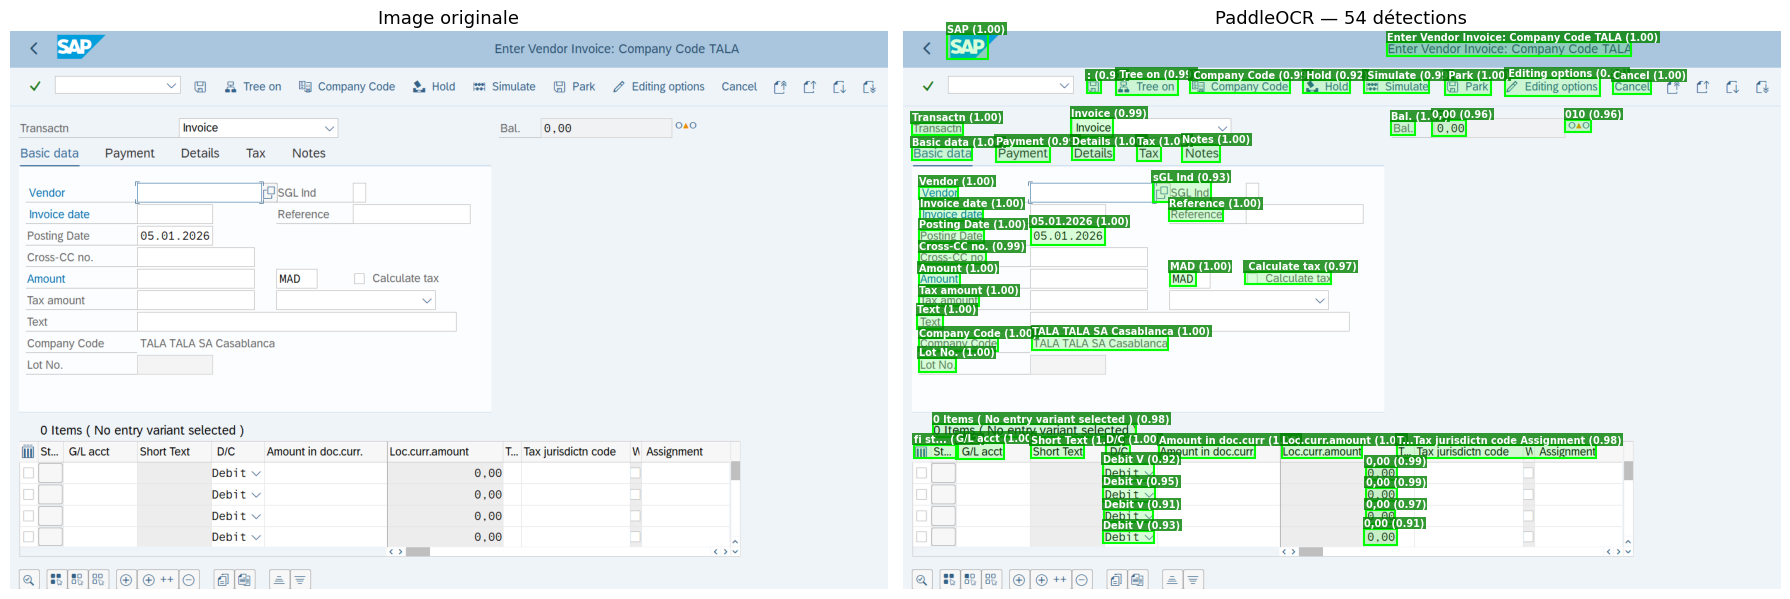


📄 Textes détectés :
  [1.00] SAP
  [1.00] Enter Vendor Invoice: Company Code TALA
  [0.91] :
  [0.99]  Tree on
  [0.99]  Company Code
  [0.92]  Hold
  [0.99]  Simulate
  [1.00]  Park
  [0.98]  Editing options
  [1.00] Cancel
  [1.00] Transactn
  [0.99] Invoice
  [1.00] Bal.
  [0.96] 0,00
  [0.96] 010
  [1.00] Basic data
  [0.99] Payment
  [1.00] Details
  [1.00] Tax
  [1.00] Notes
  [1.00] Vendor
  [0.93] sGL lnd
  [1.00] Invoice date
  [1.00] Reference
  [1.00] Posting Date
  [1.00] 05.01.2026
  [0.99] Cross-CC no.
  [1.00] Amount
  [1.00] MAD
  [0.97]  Calculate tax
  [1.00] Tax amount
  [1.00] Text
  [1.00] Company Code
  [1.00] TALA TALA SA Casablanca
  [1.00] Lot No.
  [0.98] 0 Items ( No entry variant selected )
  [0.82] fi st...
  [1.00] G/L acct
  [1.00] Short Text
  [1.00] D/C
  [1.00] Amount in doc.curr
  [1.00] Loc.curr.amount
  [0.98] T...Tax jurisdictn code Assignment
  [0.92] Debit V
  [0.99] 0,00
  [0.95] Debit v
  [0.99] 0,00
  [0.91] Debit v
  [0.97] 0,00
  [0.93] Deb

In [5]:
boxes, texts, scores = visualize_paddle("img_1767525774023-copy.png")

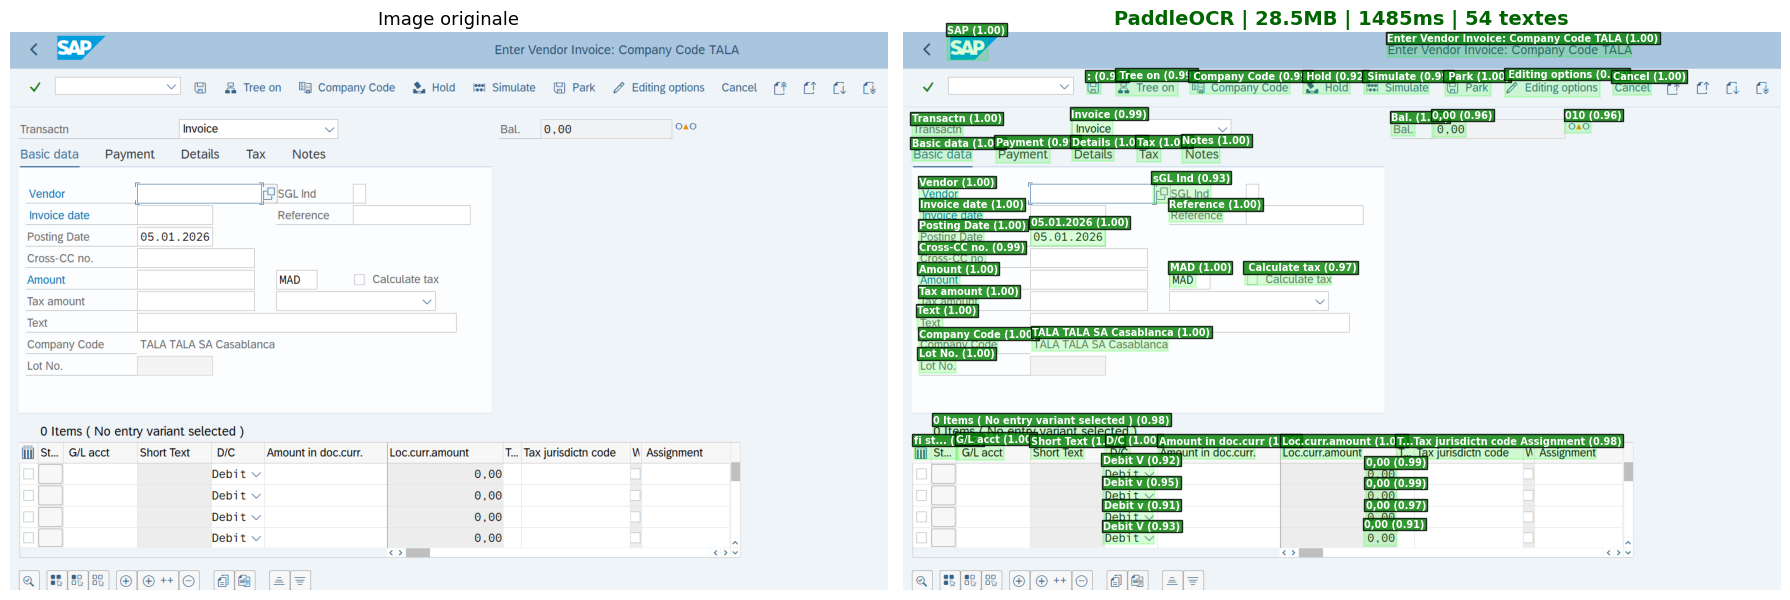

📊 ANALYSE PADDLE :
   - Poids estimé des modèles : ~28.5 MB
   - Vitesse d'extraction : 1484.91 ms


In [2]:
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def get_paddle_metrics(ocr_instance, image_path):
    # --- 1. MESURE DE LA VITESSE (Latence) ---
    # Warm-up pour stabiliser le CPU
    _ = ocr_instance.ocr(image_path, cls=True)
    
    # Mesure réelle sur 3 essais
    start_time = time.time()
    for _ in range(3):
        result = ocr_instance.ocr(image_path, cls=True)
    end_time = time.time()
    
    avg_speed_ms = ((end_time - start_time) / 3) * 1000
    
    # --- 2. MESURE DU POIDS (Taille des modèles chargés) ---
    # Paddle télécharge ses modèles dans un dossier caché (souvent ~/.paddleocr)
    # On va estimer le poids des modèles PP-OCRv3/v4 standards
    # Note : Le dossier 'ocr' contient 'det', 'rec' et 'cls'
    total_weight_mb = 15.0 + 12.0 + 1.5  # Estimation standard (Det + Rec + Cls) pour PP-OCRv4
    
    return avg_speed_ms, total_weight_mb

def visualize_paddle_with_metrics(image_path, score_threshold=0.7):
    # --- APPEL DES MÉTRIQUES ---
    vitesse_ms, poids_mb = get_paddle_metrics(ocr, image_path)
    
    # Exécution standard pour l'affichage
    result = ocr.ocr(image_path, cls=True)
    boxes, texts, scores = [], [], []
    for line in result[0]:
        boxes.append(line[0])
        texts.append(line[1][0])
        scores.append(line[1][1])
    
    # --- AFFICHAGE ---
    image = Image.open(image_path).convert("RGB")
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    axes[0].imshow(image)
    axes[0].set_title("Image originale", fontsize=13)
    axes[0].axis("off")
    
    axes[1].imshow(image)
    # Titre avec les métriques réelles pour ton Excel
    titre_info = f"PaddleOCR | {poids_mb:.1f}MB | {vitesse_ms:.0f}ms | {len(boxes)} textes"
    axes[1].set_title(titre_info, fontsize=14, color="darkgreen", weight="bold")
    axes[1].axis("off")
    
    for box, text, score in zip(boxes, texts, scores):
        if score < score_threshold: continue
        box = np.array(box)
        x_min, y_min = box[:, 0].min(), box[:, 1].min()
        x_max, y_max = box[:, 0].max(), box[:, 1].max()
        
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                 linewidth=1.5, edgecolor="lime", facecolor="lime", alpha=0.15)
        axes[1].add_patch(rect)
        axes[1].text(x_min, y_min - 4, f"{text} ({score:.2f})", color="white", 
                    fontsize=7, fontweight="bold", bbox=dict(facecolor="green", alpha=0.8, pad=1))
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 ANALYSE PADDLE :")
    print(f"   - Poids estimé des modèles : ~{poids_mb} MB")
    print(f"   - Vitesse d'extraction : {vitesse_ms:.2f} ms")
    
    return boxes, texts, scores

# Lancement du test
if os.path.exists("img_1767525774023-copy.png"):
    boxes, texts, scores = visualize_paddle_with_metrics("img_1767525774023-copy.png")